Definition of the absorption optical depth:
$$
\tau = log({I_0 \over I})
$$

Definition of the absorption Angstrom exponent:
$$
AAE = -{log(\tau_{450}/\tau_{600}) \over log(\lambda_{450}/\lambda_{600})}
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter1d
import ISSWlib as IS

In [2]:
%matplotlib notebook

In [3]:
pwd

'/home/chemistry/ISSW'

In [4]:
# Choose the spectrum folder and load in the list of spectra there
# spectrum_folder = 'Rainier_and_MtCook_comparison/'
# spectrum_folder = 'UPS_Rainier2025-07-03-01/'
# spectrum_folder = 'UCBoulder_Rainier/'
# spectrum_folder = 'UCBoulder_Baker/'
# spectrum_folder = 'UCBoulder_Adams/'
# spectrum_folder = 'UCBoulder_Misc/'
spectrum_folder = 'UPS_INKStandards/'
# spectrum_folder = 'NuCStandards/'
# spectrum_folder = 'UPS_2016Chile/'

In [5]:
spectrum_filelist = spectrum_folder+'spectrum_files.txt'
spectrum_list, number_of_loadings = IS.get_spectrum_list(spectrum_filelist)

From getline0list: In  UPS_INKStandards/spectrum_files.txt , finding these spectra:
      B.10mL.txt
      A.14mL.txt
      C.20mL.txt
      C.34mL.txt
      C.50mL.txt
      C.57mL.txt


In [6]:
# Load in the blank, and check indices
lambda_nm, I0_raw = IS.get_spectrum(spectrum_folder+'/Blank.txt')
I_450 = 100; print('lambda_450 = ',lambda_nm[I_450])
I_600 = 250; print('lambda_600 = ',lambda_nm[I_600])
I_1 = I_450
I_2 = I_600

lambda_450 =  450.0
lambda_600 =  600.0


In [7]:
# Preallocate arrays and other constants
chi_observed = np.zeros((number_of_loadings,2))
bot = np.log(lambda_nm[I_1]/lambda_nm[I_2])

<IPython.core.display.Javascript object>


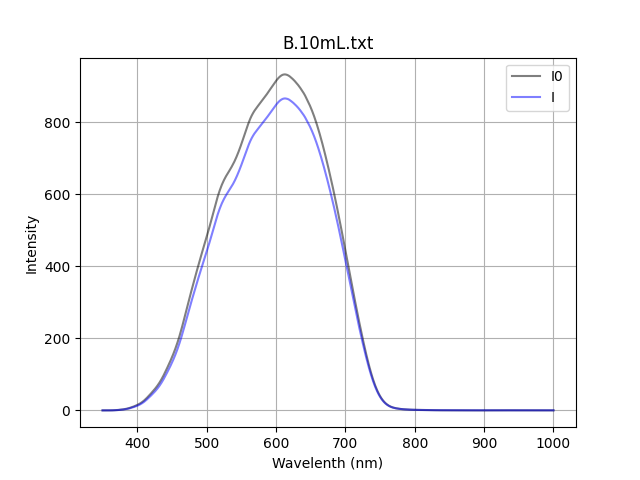

<IPython.core.display.Javascript object>


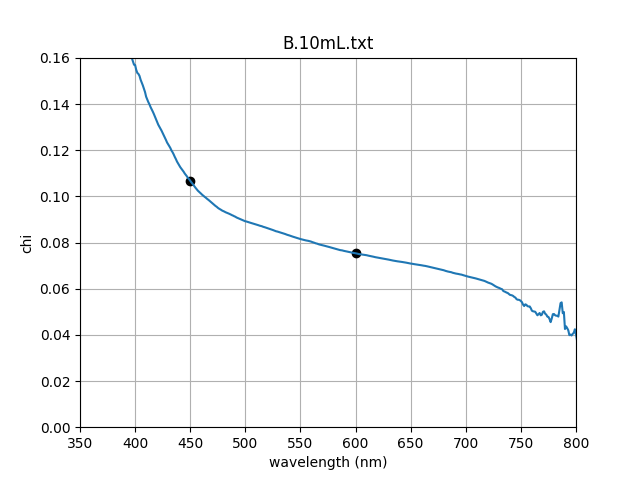

Quitting after iter =  399  w/error =  nan
Quitting after iter =  399  w/error =  nan


/home/chemistry/ISSW/ISSWlib.py:153: RuntimeWarning: invalid value encountered in log
  tau = (chi - np.log(top/bot))/2


TypeError: unsupported operand type(s) for /: 'tuple' and 'tuple'

In [8]:
for i in range(number_of_loadings):
    
    # Extract the spectrum for this item in the list
    spectrum_filename = spectrum_list[i]
    lambda_nm, I_raw = IS.get_spectrum(spectrum_folder+spectrum_filename)
    
    # Smooth and shift
    I, I0 = IS.smooth_and_shift(I_raw,I0_raw)
    
    # Get the observed chi-values
    chi = IS.get_chi_obs(I,I0,lambda_nm, title=spectrum_filename)
    
    # Save chi values at lambda1 and lambda2
    chi_observed[i,0] = chi[I_1]
    chi_observed[i,1] = chi[I_2]
    
    # Get the tau values associated with these two points
    tau_1 = IS.invert_chi_theory(chi[I_1])
    tau_2 = IS.invert_chi_theory(chi[I_2])
    
    

    
    # Get the Angstrom exponent
    top = np.log(tau_1/tau_2)
    AAE = -top/bot
    
    # Record for plotting later
    if i==0:
        AAElist = AAE
        Ilist = I
        tau_1list = tau_1
        tau_2list = tau_2
    else:
        AAElist = np.append(AAElist,AAE)
        Ilist = np.vstack((Ilist,I))
        tau_1list = np.append(tau_1list,tau_1)
        tau_2list = np.append(tau_2list,tau_2)

In [ ]:
# Getting equivalent loadings
beta1 = 8.9 # This is in m^2/g, for 450 and 600 nm
beta2 = 6.5
L_1list = tau_1list*100/beta1
L_2list = tau_2list*100/beta2

In [ ]:
# Reporting
for i in range(number_of_loadings):
    print('For ',spectrum_list[i],', L1 =', L_1list[i],', L2 =', L_2list[i],', AAE =', AAElist[i])

In [ ]:
# # Plotting to visualize the AAE values as slopes in this space
# plt.figure()
# for i in range(number):
#     tau_normalized = taulist[i]/taulist[i][I_1]
#     plt.loglog(lambda_nm[I_1],tau_normalized[I_1],'ko')
#     plt.loglog(lambda_nm[I_2],tau_normalized[I_2],'ko')
#     plt.loglog(lambda_nm,tau_normalized,label=spectrum_list[i])
#     plt.xlabel('wavelength (nm)')
#     plt.ylabel('optical depth, tau')
#     plt.xlim([400,750])
#     plt.ylim([0.5,1.1])
#     plt.title('All spectra (normalized)')
#     plt.grid(True)
#     plt.legend()